## Interpolation Scheme for BaSTI WD Models

**Input**: 
- BaSTI DA/DB cooling sequences for WD masses 0.54 - 1.1 Msun (approx. solar metallicity models, Z=0.01 and mpoor for masses > 0.9-1.0 which don't have Z=0.01). 
- Cummings+18 IFMR
- MS lifetimes fit parameters

**Method**: 
- Standartization of the Teff grid
- 1d cubic spline interpolation for the refinement of mass and age resolution 
- Calculate WD progenitor masses Mini using IFMR
- Find total age of WD by calculating MS lifetime of the progenitor for a range of metallicities
- Select mono-age data points to construct isochrones

**Output**: WD isochrones for the model age-metallicity grid

In [ ]:
import os
import shutil
import numpy as np
from astropy.table import Table
from scipy.interpolate import interp1d, PchipInterpolator

import matplotlib as mpl
import matplotlib.pyplot as plt

from jjmodel.input_ import p
from jjmodel.funcs import log_luminosity, log_surface_gravity
from helpers import IFMRHandler, MSAgeHandler


### 1. Data exploration 

#### BaSTI WD models 

BaSTI WD cooling sequences for masses 0.54 - 1.1 Msun with an irregular mass step.
High-mass WDs not included. Mass grid is the same for DA and DB. 

#### Data Properties

There is **no unified Teff grid** used across different cooling sequences like in Montreal models. 

This data cannot be directly transformed into WD isochrones because:

- Absence of the common Teff grid (or any other common column X between cooling sequence tables)
  does not allow to extract rows for same-X values from the different mass grid for interpolation. Thus, a reliminary step is required to regularize Teff first. 

- Mass resolution is too low (there will be max 9 points per curve)

- Ages that follow from Teff 

    - Form a grid with the resolution that is too low with respect to the grid used in our modelling (0.05 Gyr)

    - Do not correspond to the same age grid for the different masses. This, points of an "isochrone" constructed from this data will correspond to the different age bins, and isochrones won't be  smooth (illustrated below).


In [ ]:

def read_wdcs(masses,model='DA',data_dir='./wdcs',format='txt'):
    '''Simple function for reading cooling sequence tables'''

    cooling_sq = {mass:[] for mass in masses}
    dir_model = os.path.join(data_dir, model, 'Table_Mass')

    for mass in masses:
        try:
            filename = os.path.join(dir_model, f'Table_Mass_{mass}_{model}.{format}')
            data = np.loadtxt(filename).T
            cooling_sq[mass] = data
        except:
            # Not all masses are availale for DB
            print(f'Did not find file for mass {mass}: {filename}')

    return cooling_sq


def plot_wdcs(cooling_sq,col_idx,cmap=mpl.colormaps['managua_r'],dir_out='./'):
    '''Basic visualization of the WD cooling sequences: CMD and Kiel diagrams'''

    models = list(cooling_sq.keys())

    # CMD
    # ----------------------------------------

    fig, ax = plt.subplots(1, 2, figsize=(12,4.5), sharey=True)

    ax[0].set_ylabel(r'$\mathrm{M_G}$')
    ax[0].arrow(0.6,7.0,0,2, head_width=0.04, head_length=0.5, fc='grey', ec='grey')
    ax[0].text(0.65,9.8, r'$\mathrm{WD \ mass}$', color='grey', rotation=90)

    for i, model in enumerate(models):
        ax[i].set_title(model)
        ax[i].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$')
        for sequence in cooling_sq[model].values():
            try:
                age = 10**sequence[col_idx['age']]/1e9  # in Gyr
                gaia_mag = sequence[col_idx['G']]
                gaia_color = gaia_mag - sequence[col_idx['G_RP']]
                cax = ax[i].scatter(gaia_color, gaia_mag, c=age, 
                                    marker='o', s=5, cmap=cmap, vmin=0, vmax=14)
                ax[i].set_ylim(23,4)
            except:
                pass

    fig.subplots_adjust(right=0.88,wspace=0.1)
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label(r'$\mathrm{age_{\, WD}, \ Gyr}$')
    fig.savefig(os.path.join(dir_out,'wdcs_cmd.png'))


    # HR diagram 
    # --------------------------------------
    fig, ax = plt.subplots(1, 2, figsize=(12,4.5), sharey=True)

    ax[0].set_ylabel(r'$\mathrm{log(L/_/odot)}$')
    #ax[0].arrow(0.6,5.5,0,0.5, head_width=0.06, head_length=0.15, fc='grey', ec='grey')
    #ax[0].text(0.55,6.3, r'$\mathrm{WD \ mass}$', color='grey', rotation=90)

    for i, model in enumerate(models):
        ax[i].set_title(model)
        ax[i].set_xlabel(r'$\mathrm{log(T_{eff}/10^3)}$')
        for sequence in cooling_sq[model].values():
            try:
                age = 10**sequence[col_idx['age']]/1e9  # in Gyr
                logg = sequence[col_idx['logL']]
                logTeff = np.log10(10**sequence[col_idx['Teff']]/1e3)
                cax = ax[i].scatter(logTeff, logg, c=age, 
                                    marker='o', s=5, cmap=cmap, vmin=0, vmax=14)
                ax[i].set_ylim(-6,3)
                ax[i].set_xlim(2.5,0)
            except:
                pass

    fig.subplots_adjust(right=0.88,wspace=0.1)
    cbar = fig.colorbar(cax, ax=ax, orientation='vertical', pad=0.05)
    cbar.set_label(r'$\mathrm{age_{\, WD}, \ Gyr}$')
    fig.savefig(os.path.join(dir_out,'wdcs_hrd.png'))


In [ ]:
# Info: I store CS under base_dir/DA/Table_Mass and base_dir/DB/Table_Mass

base_dir = './BaSTI_WD_models' 
models=['DA','DB'] 

masses = {'DA_str':['0.54','0.61','0.68','0.77','0.87','1.0','1.1'],
          'DB_str':['0.54','0.61','0.68','0.77','0.87','1.0','1.1']
          }
masses['DA'] = np.array(masses['DA_str'],dtype=float)
masses['DB'] = np.array(masses['DB_str'],dtype=float)

# Columns of interest and their positions 
# Here age is WD cooling time, not total age!
col_idx = {'age':0,'Teff':2,'logL':3,'G':14,'G_BP':15,'G_RP':16}  

In [4]:
# Load the data

da_tabs = read_wdcs(masses['DA_str'],model='DA',data_dir=base_dir)
db_tabs = read_wdcs(masses['DB_str'],model='DB',data_dir=base_dir)

cooling_sq = {'DA':da_tabs,'DB':db_tabs}


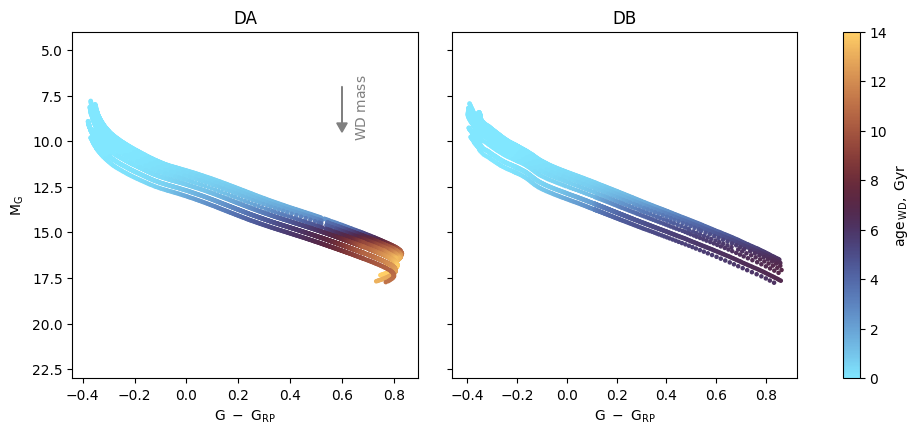

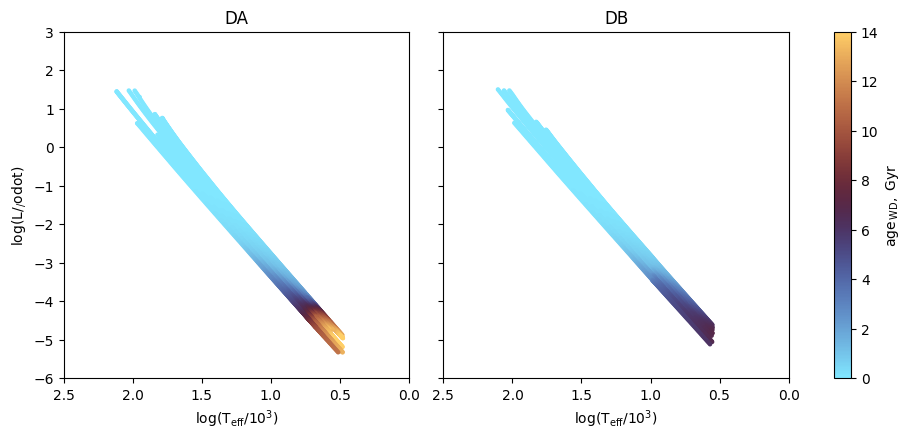

In [5]:
# Plot CS
plot_wdcs(cooling_sq,col_idx,dir_out=base_dir)

In [ ]:

def regularize_teff(cooling_sq,teff_grid_reg,col_idx):
    ''' 
    Interpolative Teff column to calculate all quantities for a standartized grid.
    '''
        
    colnames = ['Teff','age','logL','G','G_BP','G_RP']

    cooling_sq_reg = {key:{} for key in cooling_sq.keys()}

    for model in cooling_sq.keys():

        for mass in cooling_sq[model].keys():

            seq = cooling_sq[model][mass]

            teff_column = 10**seq[col_idx['Teff']]/1e3

            teff_min = teff_column.min()
            teff_max = teff_column.max()
            #print(teff_min,teff_max)
            ind_max = np.where(teff_grid_reg > teff_min)[0][-1]
            ind_min = np.where(teff_grid_reg < teff_max)[0][0]

            seq_reg = np.zeros((6,ind_max - ind_min))
            seq_reg[0] = teff_grid_reg[ind_min:ind_max]*1e3

            for i,colname in enumerate(colnames[1:]):

                q_column = seq[col_idx[colname]]
                spline = interp1d(teff_column,q_column)

                q_column_regular = spline(teff_grid_reg[ind_min:ind_max])
                seq_reg[i+1] = q_column_regular
            
            cooling_sq_reg[model][mass] = {name:seq_reg[pos] for pos,name in enumerate(colnames)}

    return cooling_sq_reg


In [ ]:
# Interpolate Teff
#-------------------------------------

# Define standard Teff grid similar to the one used in Montreal models 
# (resolution is good, but not too many points)
# Important! Here I had to lower the max Teff in the grid with respect to the available values
# for some masses, such that the chosen Teff_max is available for all masses >= 0.61 MSun. 
# Otherwise the function get_min_mass_for_teff() won't work properly. 
# (For details - increase max value in teff_grid_reg and rerun). 

g1 = np.arange(1.5, 5.5, 0.25)
g2 = np.arange(5.5, 17.5, 0.5)
g3 = np.arange(20, 65, 5)
g4 = np.arange(65, 67, 1)
teff_grid_reg = np.concatenate((g1,g2,g3,g4))[::-1]

#np.round(np.arange(78.5,2.9,-0.1),2)

cooling_sq_reg = regularize_teff(cooling_sq,teff_grid_reg,col_idx)


### 2. Cooling Sequence Interpolation

To obtain good-quality isochrones, WD cooling sequences need to be interpolated 

 - in WD mass (enough points per curve)

 - in WD age (single-age curve rather than points for an age range + enough ages)

#### 2.1 Interpolation in mass

To calculate all columns for additional masses, we need 

- Find min mass at which the WD starts cooling from a given Teff 
(low-mass WD start cooling from lower temperatures, so for a given mass we need to know which part of Teff grid is covered)

- Express each column as a function of mass on the available Teff grid and 

- Calculate their values on the 2d-grid {Teff, new_masses}


In [8]:
def get_min_mass_for_teff(
        cooling_sq,
        masses,
        teff_grid,
        model='DA',
        dir_out='./',
        xlim=(0.2,1.35),
        ylim=(0,90),
        ):
    '''
    Returns the lower WD mass limit for the CS starting-point Teff.
    Look at the plot for a better understanding. 
    '''
    masses_model = []
    min_mass_teff = []
    max_teff_mass = []
    real_teff_grid = []
    
    teff_min = 100 
    teff_max = 1

    for mass,sequence in cooling_sq.items():
        teff_mass = sequence['Teff']/1e3 # temperature grid for this mass
        max_teff_mass.append(max(teff_mass)) # get max value
        masses_model.append(float(mass)) 

        teff_min = np.min([teff_min,teff_mass.min()])
        teff_max = np.max([teff_max,teff_mass.max()])                

    ind_max = np.where((teff_grid - teff_min)<0)[0][0] - 1 
    ind_min = np.where((teff_grid - teff_max)<0)[0][0]

    # Interpolate masses at the slope part (m < 0.6 Msun)        
    spline = interp1d(max_teff_mass,masses_model)

    real_teff_grid = teff_grid[ind_min:ind_max]
    
    for t in teff_grid[ind_min:ind_max]:
        if t >= max_teff_mass[0]:
            min_mass_teff.append(np.round(spline(t),2))
        else:
            min_mass_teff.append(masses[0])

    fig, ax = plt.subplots(1,1,figsize=(8,6))
    ax.set_title(r'$\mathrm{Max(T_{eff})}$' + f' available for {model} CS at a given mass')
    ax.plot(masses_model,max_teff_mass,marker='o',markersize='5')
    ax.plot(min_mass_teff,real_teff_grid,lw=0.5,c='r')
    ax.set_xlabel(r'$\mathrm{mass_{\, WD}, \ M_\odot}$')
    ax.set_ylabel(r'$\mathrm{max(T_{eff}), \ 10^3 \, K}$')
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlim(xlim[0],xlim[1])
    plt.legend(loc=4)
    fig.savefig(os.path.join(dir_out,f'max_Teff_vs_mass_{model}.png'))

    return min_mass_teff, real_teff_grid

In [9]:

def interpolate_mass(cooling_sq,quantity,mass_grid,min_mass_teff,teff_grid,
                     model='DA',log_scale=False,norm_factor=1,label='',ylim=(0,1),dir_out='./',
                     cmap = mpl.colormaps['viridis']):
    '''
    Extract iso-temperature sequences for a specified CS column. 
    For each sequence (Teff):
      - Perform spline fit of the quantity against the Wd mass
      - Calculate quantity over the new finer mass grid
    Returns a merged column for the cooling sequences for a fine mass resolution
    '''
    # Output lists
    mass_col, q_col = [], []

    available_masses = np.array([mass for mass in cooling_sq.keys()])
    available_masses_ar = np.array(available_masses,dtype=float)
    
    # Construct the plot in parallel
    fig, ax = plt.subplots(1, 1, figsize=(8,6))

    # Define cmap
    cmap = mpl.colormaps['viridis']
    norm = mpl.colors.Normalize(vmin=teff_grid.min(), vmax=teff_grid.max())
    colors = cmap(norm(teff_grid))
    colors = cmap(np.linspace(0, 1, len(teff_grid)))[::-1]

    # Go over all temperatures and collect column values for different masses 
    # (where this temperature is available)
    for i,t in enumerate(teff_grid):

        q_masses = []
        for mass in available_masses:
            sequence = cooling_sq[mass]

            # get Teff column for this mass
            teff_mass = np.round(sequence['Teff']/1e3,2)

            if t in teff_mass:
                teff_idx = np.where(teff_mass == t)[0][0]
                q_mass = sequence[quantity][teff_idx]/norm_factor
                if quantity == 'age':
                    q_mass = 10**q_mass/1e9 # in Gyr
                if log_scale:
                    q_mass = np.log10(q_mass)
                q_masses.append(q_mass)
            else:
                q_masses.append(np.nan)
                
        q_masses = np.array(q_masses)
        mask = np.isfinite(q_masses)

        # Plot extracted iso-temperature sequences
        ax.scatter(available_masses_ar, q_masses, s=15, marker='o',color=colors[i])

        if len(q_masses[mask]) < 2:
            # Check if interpolation possible
            print('Teff =', t, 'K: Interpolation is not possible, len(mask) =', 
                  len(q_masses[mask]))
            continue
        elif len(q_masses[mask]) == 2: 
            # If only two points - simple linear interpolation
            #print(available_masses[mask])
            spline = interp1d(available_masses_ar[mask], q_masses[mask])
        else:
            # Otherwise cubic spline with suppressed overshooting 
            # (doesn't distort data shape near the boundaries)
            spline = PchipInterpolator(available_masses_ar[mask], q_masses[mask])
        
        # Find indices of min-max masses relevant for this Teff
        lim1 = np.where(mass_grid >= min_mass_teff[i])[0][0]
        lim2 = np.where(mass_grid <= max(available_masses_ar[mask]))[0][-1] + 1
        #print('max_mass:', mass_grid[lim2])
        
        # Interpolate and add to the plot
        q_masses_interpolated = spline(mass_grid[lim1:lim2])
        mass_col.extend(mass_grid[lim1:lim2])
        q_col.extend(q_masses_interpolated)

        ax.plot(mass_grid[lim1:lim2], q_masses_interpolated, c='grey', lw=0.25)

    # Finish plotting
    ax.set_xlabel(r'$\mathrm{mass_{\, WD}, \ M_\odot}$')
    ax.set_ylabel(label)
    ax.set_ylim(ylim)
    fig.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.15)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cax = fig.colorbar(sm, ax=ax)
    cax.set_label(r'$\mathrm{T_{eff}, \ 10^3 \ K}$')
    fig.savefig(os.path.join(dir_out, model + '_interp_' + quantity + '.png'))
    
    return (mass_col, q_col), (fig, ax)


In [ ]:

# Define fine-resolution WD mass grid (same for Montreal, LPCODE, and BaSTI)
mass_step = 0.002 # Msun 
mass_grid = np.round(np.arange(0.54,1.1 + 2*mass_step,mass_step),3)


/tmp/ipykernel_435399/1290275106.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc=4)


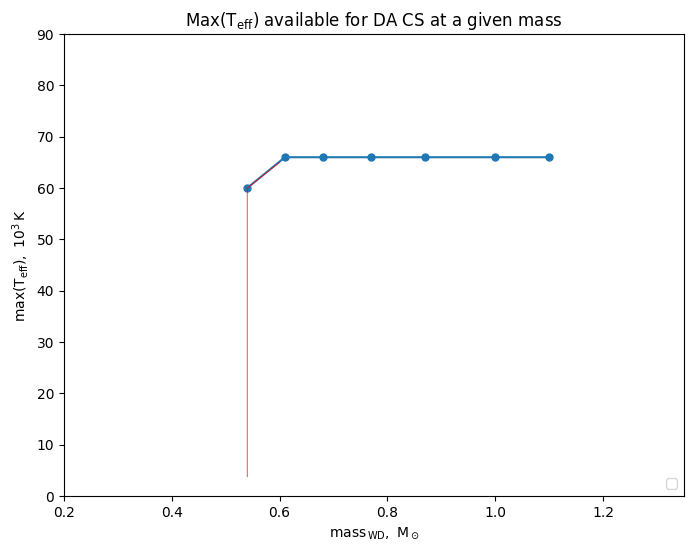

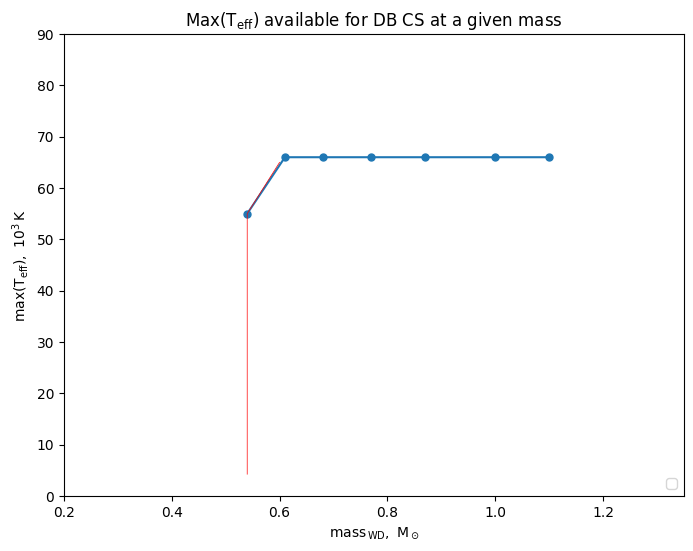

In [11]:

min_mass_teff_da, real_teff_grid_da = get_min_mass_for_teff(
    cooling_sq_reg['DA'],
    masses['DA'],
    teff_grid_reg,
    model='DA',
    dir_out=base_dir
    )

min_mass_teff_db, real_teff_grid_db = get_min_mass_for_teff(
    cooling_sq_reg['DB'],
    masses['DB'],
    teff_grid_reg,
    model='DB',
    dir_out=base_dir
    )

min_mass_teff = {'DA':min_mass_teff_da,'DB':min_mass_teff_db}
real_teff_grid = {'DA':real_teff_grid_da,'DB':real_teff_grid_db}


In [ ]:
# Perform mass interpolation for all columns
# -------------------------------------------

params = {
    'age':{
        'log_scale':False,                          # Fit in log scale - True/False
        'norm_factor':1,                          # Normalize column prior to fitting
        'label':r'$\mathrm{age_{\, WD}, \ Gyr}$',   # Label for the plot
        'ylim':(-0.5, 16)                           # Y-axis range
        },
    'logL':{
        'log_scale':False,
        'norm_factor':1,
        'label':r'$\mathrm{\log{L/L_\odot}}$',
        'ylim':(-6,3)
        },
    'Teff':{
        'log_scale':False,
        'norm_factor':1e3,
        'label':r'$\mathrm{Teff}$',
        'ylim':(0,90)
        },
    'G':{
        'log_scale':False,
        'norm_factor':1,
        'label':r'$\mathrm{G}$',
        'ylim':(23,3)
        },
    'G_BP':{
        'log_scale':False,
        'norm_factor':1,
        'label':r'$\mathrm{G_{BP}}$',
        'ylim':(23,3)
        },
    'G_RP':{
        'log_scale':False,
        'norm_factor':1,
        'label':r'$\mathrm{G_{RP}}$',
        'ylim':(23,3)
        }
}


# Apply to the BaSTI data 
cooling_sq_m = {model:Table() for model in models}

for model in models:

    dir_out = os.path.join(base_dir,model)

    for quantity in params.keys():
        (mass, column), (fig, ax) =\
            interpolate_mass(cooling_sq_reg[model],
                             quantity,
                             mass_grid,
                             min_mass_teff[model],
                             real_teff_grid[model],
                             model=model,
                             log_scale=params[quantity]['log_scale'],
                             norm_factor=params[quantity]['norm_factor'],
                             label=params[quantity]['label'],
                             ylim=params[quantity]['ylim'],
                             dir_out=dir_out
                            );
        plt.close()    
        cooling_sq_m[model][quantity] = column

    cooling_sq_m[model]['mass'] = mass

#### 2.2 Age Interpolation

In [14]:
# Define a fine-resolution age grid consistent with the one used for MS isochrones
# Important! Isochrones are calculated with a larger step, 0.05 Gyr, 
# but interpolation should be done for this full-resolution grid. 
# Otherwise some ages won't be found at the final step of extracting isochrones 
# from the interpolated table. 

age_step = 0.025  # Gyr
age_max = 13.0    # Gyr
age_grid = np.round(np.arange(age_step, age_max + age_step, age_step),3)


In [15]:

def interpolate_age(cooling_table,age_grid,model,quantity,mass,
                    label='',ylim=(0,1),plot=False,dir_out='./'):
    ''' 
    Similar to interpolate_mass, but for age grid and a fixed mass
    '''
    
    # Add a small noise to ages to avoid dublicated values 
    # Spline requires strictly ascending array, same values are not allowed
    age_col = np.array([val + 1e-4*np.abs(np.random.randn()) for val in cooling_table[model]['age']])
    
    # Select a cooling sequence subsequence from the big table
    mass_idx = np.where(cooling_table[model]['mass']==mass)[0]
    sort_idx = np.argsort(age_col[mass_idx])
    
    # Get age and the specified column 
    sorted_age = age_col[mass_idx][sort_idx]
    sorted_quantity = cooling_table[model][quantity][mass_idx][sort_idx]

    # Sanity check
    if len(sorted_quantity) < 2:
        print(model,' Interpolation for mass = ',mass,' Msun for ',quantity,
              ' is not possible. Skipping...')
        return None
    
    # Interpolate
    spline = PchipInterpolator(sorted_age,sorted_quantity)
                        
    # Make sure not to apply spline to ages larger than max age in the cooling sequence!
    max_age_idx = np.where(age_grid <= sorted_age[-1])[0][-1]

    age_grid_trunc = age_grid[:max_age_idx]
    q_interpolated = spline(age_grid_trunc)
    
    # Create plot if needed
    if plot:
        fig, ax = plt.subplots(1,1,figsize=(8,6))
        ax.scatter(sorted_age,sorted_quantity,marker='x',s=15,c='steelblue',
                   label='cool.seq. increased m-resolution')
        ax.plot(age_grid_trunc,q_interpolated,c='lawngreen',label='spline fit')
        ax.set_xlabel(r'$\mathrm{age_{\, WD}, \ Gyr}$')
        ax.set_ylabel(label)
        ax.text(0.08,0.9,r'$\mathrm{mass_{\, WD} \, = \,}$' + str(mass) + r'$\mathrm{\ M_\odot}$',
                transform=ax.transAxes);
        ax.set_ylim(ylim)
        plt.legend(loc=4)

        fig.savefig(os.path.join(dir_out,'age_interp_' + quantity + '_' + model + '.png'))

    return (age_grid_trunc, q_interpolated)


def interpolate_age_all_masses(cooling_table,cols_to_interpolate,mass_grid,age_grid):

    all_columns = cols_to_interpolate + ['age','mass']
    models = list(cooling_table.keys())
        
    # Output container
    cooling_sq_ma = {model:{col:[] for col in all_columns} for model in models}

    for model in models:
        print('\nInterpolating age for ' + model + ' models')
        age_col = np.array([val + 1e-4*np.abs(np.random.randn()) for val in cooling_table[model]['age']])
        
        for mass in mass_grid:
            print('\tmass:',mass)

            mass_idx = np.where(cooling_table[model]['mass']==mass)[0]
            sort_idx = np.argsort(age_col[mass_idx])
            sorted_age = age_col[mass_idx][sort_idx]

            if len(sorted_age) > 2: 
                max_age_idx = np.where(age_grid <= sorted_age[-1])[0][-1]
                age_grid_trunc = age_grid[:max_age_idx]
                cooling_sq_ma[model]['age'].extend(age_grid_trunc)
                cooling_sq_ma[model]['mass'].extend([mass for _ in np.arange(len(age_grid_trunc))])

                for col in cols_to_interpolate:  
                    sorted_quantity = cooling_table[model][col][mass_idx][sort_idx]
                    spline = PchipInterpolator(sorted_age,sorted_quantity)
                    q_interpolated = spline(age_grid_trunc)
                    cooling_sq_ma[model][col].extend(q_interpolated)

            else:
                print("\tNot enough data points for this mass, skipping for all columns")

    return cooling_sq_ma


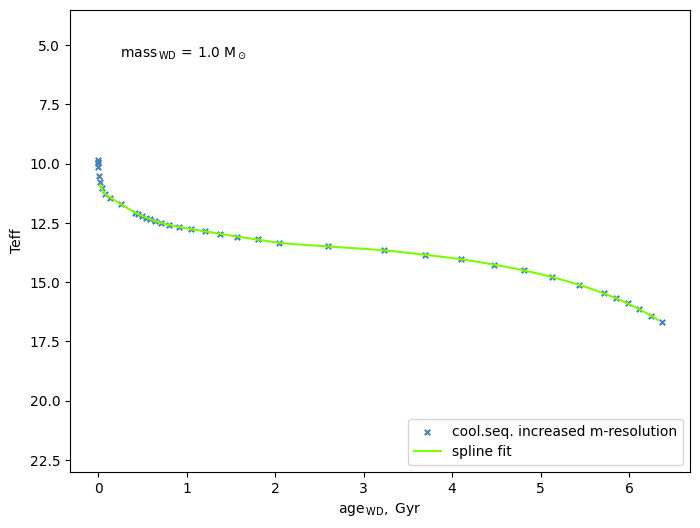

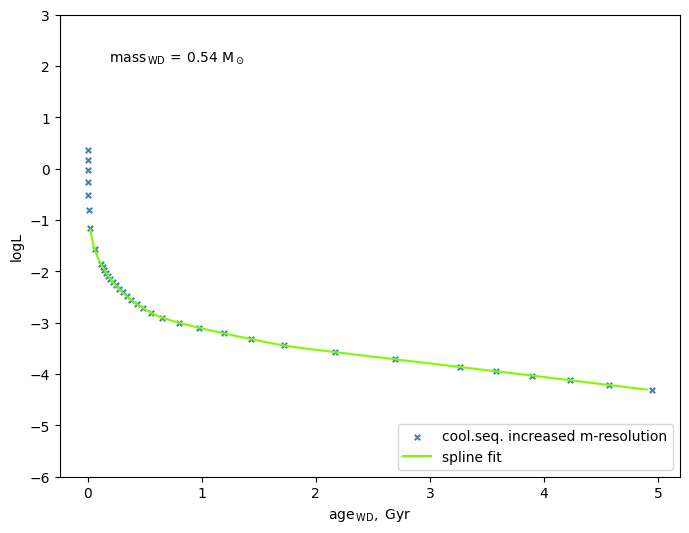

In [16]:
# Test age interpolation for a few examples

interpolate_age(cooling_sq_m,age_grid,'DB','G',1.0,
                label='Teff',ylim=(23,3.5),plot=True,dir_out=base_dir);

interpolate_age(cooling_sq_m,age_grid,'DB','logL',0.54,
                label='logL',ylim=(-6,3),plot=True,dir_out=base_dir);


In [17]:
# Apply age interpolation to all columns and all masses

cols_to_interpolate = ['Teff','logL','G','G_BP','G_RP']

cooling_sq_ma = interpolate_age_all_masses(cooling_sq_m,cols_to_interpolate,mass_grid,age_grid)



Interpolating age for DA models
	mass: 0.54
	mass: 0.542
	mass: 0.544
	mass: 0.546
	mass: 0.548
	mass: 0.55
	mass: 0.552
	mass: 0.554
	mass: 0.556
	mass: 0.558
	mass: 0.56
	mass: 0.562
	mass: 0.564
	mass: 0.566
	mass: 0.568
	mass: 0.57
	mass: 0.572
	mass: 0.574
	mass: 0.576
	mass: 0.578
	mass: 0.58
	mass: 0.582
	mass: 0.584
	mass: 0.586
	mass: 0.588
	mass: 0.59
	mass: 0.592
	mass: 0.594
	mass: 0.596
	mass: 0.598
	mass: 0.6
	mass: 0.602
	mass: 0.604
	mass: 0.606
	mass: 0.608
	mass: 0.61
	mass: 0.612
	mass: 0.614
	mass: 0.616
	mass: 0.618
	mass: 0.62
	mass: 0.622
	mass: 0.624
	mass: 0.626
	mass: 0.628
	mass: 0.63
	mass: 0.632
	mass: 0.634
	mass: 0.636
	mass: 0.638
	mass: 0.64
	mass: 0.642
	mass: 0.644
	mass: 0.646
	mass: 0.648
	mass: 0.65
	mass: 0.652
	mass: 0.654
	mass: 0.656
	mass: 0.658
	mass: 0.66
	mass: 0.662
	mass: 0.664
	mass: 0.666
	mass: 0.668
	mass: 0.67
	mass: 0.672
	mass: 0.674
	mass: 0.676
	mass: 0.678
	mass: 0.68
	mass: 0.682
	mass: 0.684
	mass: 0.686
	mass: 0.688
	mass: 0

In [ ]:

def get_progenitor_mass(cooling_table):
    '''Application of IFMR'''

    models = list(cooling_table.keys())

    ifmr = IFMRHandler(p)

    for model in models:
        # Here index 0 - progenitor mass, index 1 - its uncertainty
        cooling_table[model]['mini'] =\
            [ifmr.cummings_r(mass_wd)[0] for mass_wd in cooling_table[model]['mass']]
        
    return cooling_table
        

In [19]:
# Calculate progenitor mass based on the WD masses
cooling_sq_ma = get_progenitor_mass(cooling_sq_ma)

In [20]:
# Read metallicity grid 
# old
#metgrid = np.loadtxt('../../jjmodel/jjmodel/input/isochrones/Metallicity_grid.txt').T[1]

# new
metgrid = np.loadtxt('../../isochrones/grids/metgrid_linFeH.txt').T[1]

FeH_grid = np.sort(metgrid)
FeH_grid = np.round(FeH_grid,2)

In [ ]:

def create_isochrones(cooling_table,FeH_grid,age_grid,iso_col_names,
                      param_file='./tau_ms_params.txt',dir_out='./'):

    '''Final step - extract single-age data points 
    from the full interpolated table = isochrone

    Apply to all metallicities. 
    '''

    tab = cooling_table.copy()
    models = list(tab.keys())

    age_step = age_grid[1] - age_grid[0]

    agefit = MSAgeHandler(param_file=param_file)

    for model in models:
        print('\nCreating isochrones for ' + model + ' models')

        for met in FeH_grid:
            print('\t[Fe/H] = ',str(met))

            # Create metallicity folder 
            feh_dir = os.path.join(dir_out,model,'isochrones','iso_fe'+str(met))
            os.makedirs(feh_dir,exist_ok=True)

            # Derive MS lifetime and total age
            tab[model]['age_ms'] = agefit.get_age_ms(tab[model]['mini'],feh=met)
            tab[model]['age_tot'] = tab[model]['age'] + tab[model]['age_ms']
            tab[model]['age_tot'] = age_step*\
                                    (tab[model]['age_tot']//age_step +\
                                    np.round((tab[model]['age_tot']%age_step)/age_step,0)
                                    )
            
            for age_value in age_grid:
                
                age_value = np.round(age_value,3)
                # Select all stars with a given age
                iso_idx = np.where(np.round(tab[model]['age_tot'],3)==age_value)[0]
                
                if len(iso_idx) > 0:
                    col_mini_iso = np.array(tab[model]['mini'])[iso_idx]

                    # Remove duplicates
                    unique_mini = np.unique(col_mini_iso)
                    unique_idx = np.array([np.where(col_mini_iso==m)[0][0] for m in unique_mini])

                    sort_idx = np.argsort(col_mini_iso[unique_idx])

                    # Construct isochrone
                    output = Table()
                    for col in tab[model].keys():
                        if col not in ['age_tot','age_ms']:
                            col_iso = np.array(tab[model][col])[iso_idx]
                            output[col] = col_iso[unique_idx][sort_idx]

                            if col == 'Teff':
                                output[col] = np.log10(1e3*output[col])

                    # Add logL column
                    output['logg'] = log_surface_gravity(output['mass'],10**output['mass'],10**output['Teff'])
                    
                    order = ['mini','mass','logL','Teff','logg','age','G','G_BP','G_RP']
                    output = output[order]

                    filename = os.path.join(feh_dir, 'iso_age' + str(round(age_value,3)) + '.txt')
                    col_names = [iso_col_names[key] for key in output.keys() 
                                if key not in ['age_ms','age_tot']]

                    output.write(filename,names=col_names,format='ascii.fixed_width',delimiter=' ',
                                exclude_names=['age_ms','age_tot'],
                                formats={key:'%10.5f' for key in col_names},overwrite=True
                                )
                    
                    # Patch for header
                    with open(filename) as f:
                        lines = f.readlines()

                    with open(filename, "w") as f:
                        f.write("#" + lines[0][1:])   # header with hash
                        f.writelines(lines[1:])       # rest unchanged
                else:
                    print('[Fe/H] = ' + str(met) + ': age ' + str(age_value) + ' Gyr is empty')
                    pass

    print('Done')
    

In [23]:
iso_col_names = {'mini':'Mini','mass':'Mass','age':'age_WD',
                 'Teff':'logTe','logL':'logL','logg':'logg',
                 'G':'Gmag_EDR3','G_BP':'G_BPmag_EDR3','G_RP':'G_RPmag_EDR3'} # 

# Read parameters for MS lifetime fits
# old metgrid
#param_file = 'MS_lifetime_padova/analysis/fit_v1_Mbr1.2/tau_ms_params_v1_Mbr1.2.txt'
# new metgrid
param_file = 'MS_lifetime_padova_new_metgrid/analysis/fit_v1_Mbr1.18/tau_ms_params_v1_Mbr1.18.txt'

age_step = 0.05 # Gyr, age resolution of isochrones (x2 rougher than the actual model grid!)
age_grid_rough = np.arange(age_step,age_max + age_step,age_step)

create_isochrones(
    cooling_sq_ma,
    FeH_grid,
    age_grid_rough,
    iso_col_names,
    param_file=param_file,
    dir_out=base_dir
    );



Creating isochrones for DA models
	[Fe/H] =  -2.8
	[Fe/H] =  -2.7
	[Fe/H] =  -2.6
	[Fe/H] =  -2.5
	[Fe/H] =  -2.4
	[Fe/H] =  -2.3
	[Fe/H] =  -2.2
	[Fe/H] =  -2.1
	[Fe/H] =  -2.0
	[Fe/H] =  -1.9
	[Fe/H] =  -1.8
	[Fe/H] =  -1.7
	[Fe/H] =  -1.6
	[Fe/H] =  -1.5
	[Fe/H] =  -1.45
	[Fe/H] =  -1.4
	[Fe/H] =  -1.35
	[Fe/H] =  -1.3
	[Fe/H] =  -1.25
	[Fe/H] =  -1.2
	[Fe/H] =  -1.15
	[Fe/H] =  -1.1
	[Fe/H] =  -1.05
	[Fe/H] =  -1.0
	[Fe/H] =  -0.95
	[Fe/H] =  -0.9
	[Fe/H] =  -0.85
	[Fe/H] =  -0.8
	[Fe/H] =  -0.75
	[Fe/H] =  -0.7
	[Fe/H] =  -0.65
	[Fe/H] =  -0.6
	[Fe/H] =  -0.55
	[Fe/H] =  -0.5
	[Fe/H] =  -0.45
	[Fe/H] =  -0.4
	[Fe/H] =  -0.38
	[Fe/H] =  -0.36
[Fe/H] = -0.36: age 0.05 Gyr is empty
	[Fe/H] =  -0.34
[Fe/H] = -0.34: age 0.05 Gyr is empty
	[Fe/H] =  -0.32
	[Fe/H] =  -0.3
	[Fe/H] =  -0.28
[Fe/H] = -0.28: age 0.05 Gyr is empty
	[Fe/H] =  -0.26
	[Fe/H] =  -0.24
	[Fe/H] =  -0.22
	[Fe/H] =  -0.2
[Fe/H] = -0.2: age 0.05 Gyr is empty
	[Fe/H] =  -0.18
[Fe/H] = -0.18: age 0.05 Gyr is empty
	[Fe

In [ ]:
# Patch:
# the lowest age of 0.05 Gyr is not available, this causes problems when using 
# such incomplete grid with the JJ model. So I create this missing file as a 
# renamed copy of the lowest available age, 0.1 Gyr.  

for model in models:
    for feh in FeH_grid:
        try:
            # Read isochrone
            dir = os.path.join(base_dir,model,'isochrones','iso_fe'+str(feh))
            iso_name = os.path.join(dir,'iso_age0.05.txt')
            iso = np.loadtxt(iso_name)
        except:
            iso_name_sub = os.path.join(dir,'iso_age0.1.txt')
            shutil.copy(iso_name_sub, iso_name)


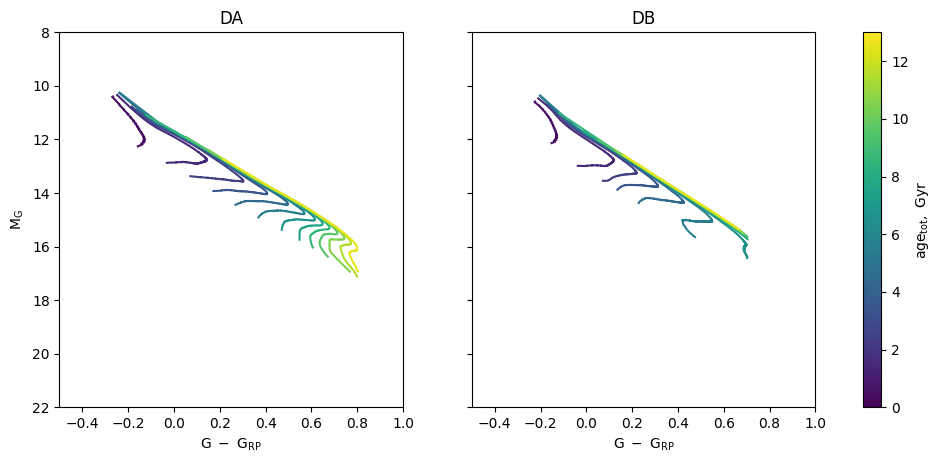

In [25]:
# Plot old BaSTI and new Montreal isochrones for a set of test ages 
# -----------------------------------------------------------------

test_ages = np.arange(0.5,13.5,1)
#test_ages = [12.0]

test_feh = 0 # dex, test metallicity

mod1, mod2 = models, ['H','He']

fig, ax = plt.subplots(1,2,figsize=(10.5,5),sharey=True)

cmap = mpl.colormaps['viridis']
norm = mpl.colors.Normalize(vmin=0, vmax=13)
colors = cmap(norm(test_ages))
#colors = cmap(np.linspace(0, 1, len(test_ages)))

for i in range(len(models)):

    for j,age in enumerate(test_ages):

        # Read isochrones
        dir1 = os.path.join(base_dir,mod1[i], # 'interpolation_new_metgrid',
                            'isochrones','iso_fe'+str(test_feh))
        dir2 = '../../jjmodel/jjmodel/input/isochrones/BaSTI/WD/multiband/' +\
               mod2[i] + '/' + 'iso_fe' + str(test_feh)
        
        file1 = os.path.join(dir1,'iso_age' + str(round(age,3)) + '.txt')
        file2 = os.path.join(dir2,'iso_age' + str(round(age,3)) + '.txt')

        iso1 = np.loadtxt(file1).T
        G1 = iso1[6]
        G_RP1 = iso1[8]
        ax[i].plot(G1 - G_RP1, G1, c=colors[j], lw=1.5)

        #iso2 = np.loadtxt(file2).T
        #G2 = iso2[6]
        #G_RP2 = iso2[8]
        #ax[i].plot(G2 - G_RP2, G2, c=colors[j],ls='--',lw=0.5)


    ax[i].set_title(mod1[i])
    ax[i].set_ylim(22,8.0)
    ax[i].set_xlim(-0.5,1.0)
    ax[i].set_xlabel(r'$\mathrm{G \ - \ G_{RP}}$')
    if i == 0:
        ax[i].set_ylabel(r'$\mathrm{M_{G}}$')

fig.subplots_adjust(left=0.1, right=1.0, top=0.9, bottom=0.15)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # required for older matplotlib
cax = fig.colorbar(sm, ax=ax)
cax.set_label(r'$\mathrm{age_{tot}, \ Gyr}$')

fig.savefig(os.path.join(base_dir,'iso_comparison_new_metgrid_u.png'))


In [ ]:
# For testing
'''
agefit = MSAgeHandler(param_file=param_file)

m = 'DB'
tab = cooling_sq_ma[m]
tab['age_ms'] = agefit.get_age_ms(tab['mini'],feh=0.0)
tab['age_tot'] = tab['age'] + tab['age_ms']
tab['age_tot_r'] = age_step*\
                    (tab['age_tot']//age_step +\
                    np.round((tab['age_tot']%age_step)/age_step,0)
                    )

plt.scatter(np.array(tab['G'])-np.array(tab['G_RP']),tab['G'],s=1,alpha=0.02)
''';